In [5]:
import pandas as pd
import numpy as np
import math
import random
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from ISLP import load_data
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score)
from sklearn.utils import resample
from sklearn.metrics import precision_recall_curve

In [6]:
data = pd.read_csv('olist_order_items_joined.csv')

In [7]:
data.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,...,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,total_payment,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,5f79b5b0931d63f1a42989eb65b9da6e,1.0,64315bd8c0c47303179dd2e25b579d00,7aa4334be125fcdd2ba64b3180029f14,2017-11-21 16:35:32,89.80,24.94,brinquedos,55.0,889.0,...,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04 00:00:00,1.0,114.74,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,a44895d095d7e0702b6a162fa2dbeced,1.0,84183944dc7cddca87a5d384452c1d3c,2a1348e9addc1af5aaa619b1a3679d6b,2017-07-20 09:55:12,54.90,12.51,beleza_saude,57.0,2563.0,...,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04 00:00:00,4.0,67.41,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,316a104623542e4d75189bb372bc5f8d,1.0,9df2b21ec85378d71df4404712e17478,46dc3b2cc0980fb8ec44634e21d2718e,2017-03-06 11:15:20,179.99,15.43,bebes,45.0,1042.0,...,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22 00:00:00,5.0,195.42,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,5825ce2e88d5346438686b0bba99e5ee,1.0,af3ec22cce878225aae6d9eb6c7a78eb,aafe36600ce604f205b86b5084d3d767,2017-08-23 03:10:27,149.90,29.45,cool_stuff,38.0,840.0,...,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14 00:00:00,5.0,179.35,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,0ab7fb08086d4af9141453c91878ed7a,1.0,868b3136c5b206f91b8208fbfdf2cb7c,4a3ca9315b744ce9f8e9374361493884,2018-04-10 03:10:19,93.00,14.01,cama_mesa_banho,57.0,364.0,...,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18 00:00:00,4.0,107.01,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP


In [8]:
data2 = pd.read_csv('olist_order_payments_joined.csv')

In [9]:
data2.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_score,total_payment,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,5f79b5b0931d63f1a42989eb65b9da6e,1.0,credit_card,8.0,114.74,00012a2ce6f8dcda20d059ce98491703,delivered,2017-11-14 16:08:26,2017-11-14 16:35:32,2017-11-17 15:32:08,2017-11-28 15:41:30,2017-12-04 00:00:00,1.0,114.74,248ffe10d632bebe4f7267f1f44844c9,6273,osasco,SP
1,a44895d095d7e0702b6a162fa2dbeced,1.0,credit_card,5.0,67.41,000161a058600d5901f007fab4c27140,delivered,2017-07-16 09:40:32,2017-07-16 09:55:12,2017-07-19 19:09:37,2017-07-25 18:57:33,2017-08-04 00:00:00,4.0,67.41,b0015e09bb4b6e47c52844fab5fb6638,35550,itapecerica,MG
2,316a104623542e4d75189bb372bc5f8d,1.0,credit_card,10.0,195.42,0001fd6190edaaf884bcaf3d49edf079,delivered,2017-02-28 11:06:43,2017-02-28 11:15:20,2017-03-01 15:24:20,2017-03-06 08:57:49,2017-03-22 00:00:00,5.0,195.42,94b11d37cd61cb2994a194d11f89682b,29830,nova venecia,ES
3,5825ce2e88d5346438686b0bba99e5ee,1.0,boleto,1.0,179.35,0002414f95344307404f0ace7a26f1d5,delivered,2017-08-16 13:09:20,2017-08-17 03:10:27,2017-08-19 11:34:29,2017-09-13 20:06:02,2017-09-14 00:00:00,5.0,179.35,4893ad4ea28b2c5b3ddf4e82e79db9e6,39664,mendonca,MG
4,0ab7fb08086d4af9141453c91878ed7a,1.0,boleto,1.0,107.01,000379cdec625522490c315e70c7a9fb,delivered,2018-04-02 13:42:17,2018-04-04 03:10:19,2018-04-04 18:11:09,2018-04-13 20:21:08,2018-04-18 00:00:00,4.0,107.01,0b83f73b19c2019e182fd552c048a22c,4841,sao paulo,SP


In [10]:
data.columns

Index(['order_id', 'order_item_id', 'product_id', 'seller_id',
       'shipping_limit_date', 'price', 'freight_value',
       'product_category_name', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_length_cm', 'product_height_cm', 'product_width_cm',
       'seller_zip_code_prefix', 'seller_city', 'seller_state', 'customer_id',
       'order_status', 'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_score', 'total_payment',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='object')

In [11]:
data2.columns

Index(['order_id', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'customer_id', 'order_status',
       'order_purchase_timestamp', 'order_approved_at',
       'order_delivered_carrier_date', 'order_delivered_customer_date',
       'order_estimated_delivery_date', 'review_score', 'total_payment',
       'customer_unique_id', 'customer_zip_code_prefix', 'customer_city',
       'customer_state'],
      dtype='object')

In [12]:
# question: What factors influence whether a customer will leave a high review score (> 4 stars)?

In [13]:
'''
Step plan:
1. Identify variables I want to use
2. Make the necessary variables
3. Put all relevant variables into a dataframe
4. Run a logistic regression
5. Finetune as much as necessary (can include regularization or cross-validation)
6. Interpret results
''';

In [14]:
'''
Variables that can be important:
- delivery delay --> order_delivered_customer_date - order_estimated_delivery_date (eliminate this one, since it is heavily correlated with toal delivery time)
- total delivery time --> make this variable: order_delivered_customer_date - order_purchase_timestamp
- product_photos_qty
- product_description_lenght (careful! typo)
- freight value relative to price --> freight_value / price
''';

In [15]:

data['delivery_delay_days'] = (pd.to_datetime(data['order_delivered_customer_date']) - 
                               pd.to_datetime(data['order_estimated_delivery_date'])).dt.days

data['total_delivery_time_days'] = (pd.to_datetime(data['order_delivered_customer_date']) - 
                                    pd.to_datetime(data['order_purchase_timestamp'])).dt.days

data['processing_time_days'] = (pd.to_datetime(data['order_approved_at']) - 
                                pd.to_datetime(data['order_purchase_timestamp'])).dt.days

data['freight_value_price'] = data['freight_value'] / data['price']

In [16]:
data['freight_value_price'].head()

0    0.277728
1    0.227869
2    0.085727
3    0.196464
4    0.150645
Name: freight_value_price, dtype: float64

In [17]:
data['delivery_delay_days'].head()

0    -6.0
1   -10.0
2   -16.0
3    -1.0
4    -5.0
Name: delivery_delay_days, dtype: float64

In [18]:
df = data[['total_delivery_time_days', 'product_photos_qty', 'product_description_lenght', 'freight_value_price']]

In [19]:
df.head()

,total_delivery_time_days,product_photos_qty,product_description_lenght,freight_value_price
0,13.0,1.0,889.0,0.277728
1,9.0,2.0,2563.0,0.227869
2,5.0,2.0,1042.0,0.085727
3,28.0,1.0,840.0,0.196464
4,11.0,2.0,364.0,0.150645


In [20]:
# so in the end I chose not to include delayed delivery days, since this was 1 to 1 correlated with total delivery time days
X = data[['total_delivery_time_days', 
          'product_photos_qty', 'product_description_lenght', 'freight_value_price']].dropna()
y = (data['review_score'] >= 4).astype(int).dropna()

In [21]:
y

0         0
1         1
2         1
3         1
4         1
         ..
113420    1
113421    1
113422    1
113423    1
113424    1
Name: review_score, Length: 113425, dtype: int32

In [22]:
y.value_counts()

review_score
1    84419
0    29006
Name: count, dtype: int64

In [23]:
data2['order_status'].value_counts()

order_status
delivered      100757
shipped          1166
canceled          664
unavailable       649
invoiced          325
processing        319
created             5
approved            2
Name: count, dtype: int64

In [24]:
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (108659, 4)
y shape: (113425,)


In [25]:
print("Missing values in X:\n", X.isnull().sum())
print("Missing values in y:\n", y.isnull().sum())

Missing values in X:
 total_delivery_time_days      0
product_photos_qty            0
product_description_lenght    0
freight_value_price           0
dtype: int64
Missing values in y:
 0


In [26]:
# Align indices of X and y
X, y = X.align(y, join='inner', axis=0)

# Check the shapes again
print("Aligned X shape:", X.shape)
print("Aligned y shape:", y.shape)

Aligned X shape: (108659, 4)
Aligned y shape: (108659,)


In [27]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.3, random_state = 3)

In [28]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [29]:
model = LogisticRegression(solver='liblinear', class_weight = 'balanced')
model.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', solver='liblinear')

In [30]:
y_test_prob = model.predict_proba(X_test)[:,1]
threshold = 0.5
y_test_custom_threshold = (y_test_prob >= threshold).astype(int)

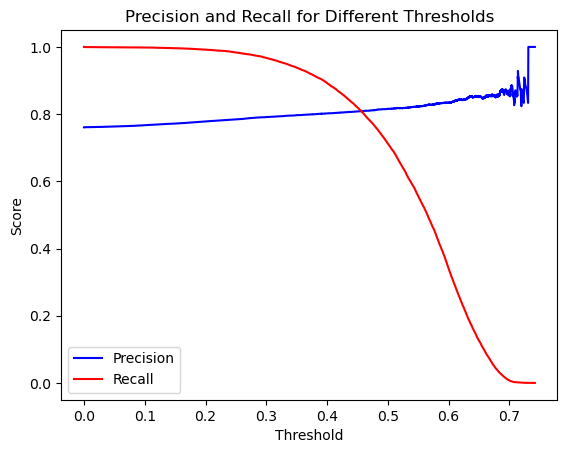

In [31]:
precision, recall, thresholds = precision_recall_curve(y_test, y_test_prob)
plt.plot(thresholds, precision[:-1], label="Precision", color="blue")
plt.plot(thresholds, recall[:-1], label="Recall", color="red")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision and Recall for Different Thresholds")
plt.legend()
plt.show()

In [32]:
param_grid = {'penalty': ['l1', 'l2'],
    'C': [0.001,0.1, 1, 10, 100,1000]}

In [95]:
grid_search = GridSearchCV(estimator=model, param_grid=param_grid, scoring='f1', cv=5) # I want to optimize for F1 score since n'either precision or recall is significantly more important
grid_search.fit(X_train, y_train)

GridSearchCV(cv=5,
             estimator=LogisticRegression(class_weight='balanced',
                                          solver='liblinear'),
             param_grid={'C': [0.001, 0.1, 1, 10, 100, 1000],
                         'penalty': ['l1', 'l2']},
             scoring='f1')

In [34]:
best_model = grid_search.best_estimator_

In [35]:
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'C': 0.1, 'penalty': 'l2'}


In [36]:
y_pred = best_model.predict(X_test)

print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.35      0.49      0.41      7789
           1       0.82      0.71      0.76     24809

    accuracy                           0.66     32598
   macro avg       0.58      0.60      0.58     32598
weighted avg       0.70      0.66      0.68     32598



In [99]:
cm = confusion_matrix(y_test, y_pred)
cm

array([[ 3797,  3992],
       [ 7144, 17665]], dtype=int64)

In [103]:
confusion_matrix = pd.DataFrame(cm, 
                                columns=['Predicted Negative', 'Predicted Positive'], 
                                index=['Actual Negative', 'Actual Positive'])
print(confusion_matrix)

                 Predicted Negative  Predicted Positive
Actual Negative                3797                3992
Actual Positive                7144               17665


In [38]:
coefficients = model.coef_[0]  # .coef_ is a 2D array, so [0] accesses the first row

feature_names = X.columns

coef_df = pd.DataFrame({'Feature': feature_names, 'Coefficient': coefficients})

print(coef_df)

                      Feature  Coefficient
0    total_delivery_time_days    -0.632641
1          product_photos_qty     0.016534
2  product_description_lenght     0.035618
3         freight_value_price    -0.050207


In [39]:
coefficients = model.coef_[0] 

# Convert log-odds to odds ratios
odds_ratios = np.exp(coefficients)

print("Odds Ratios:", odds_ratios)

Odds Ratios: [0.53118732 1.01667114 1.03626033 0.95103293]


In [40]:
'''
Interpreting the Odds Ratios
- total_delivery_time_days: every extra day odds of high review decrease by 47%
- product_photos_qty: for each additional photo, odds increase by 1.67%
- product_description_length: each extra unit, odds increase 3.63%
- freight_value_price: for each unit increase, odds decrease by 4.9%

Conclusion:
- Delivery has the greatest impact
- Product photos and description length have a smaller impact but can be easier to improve
- Shipping costs relative to price negatively impact satisfaction, it could be that customers perceive shipping costs as unfair value relative to price


''';

In [41]:
# create visuals to make interpretation of results easier

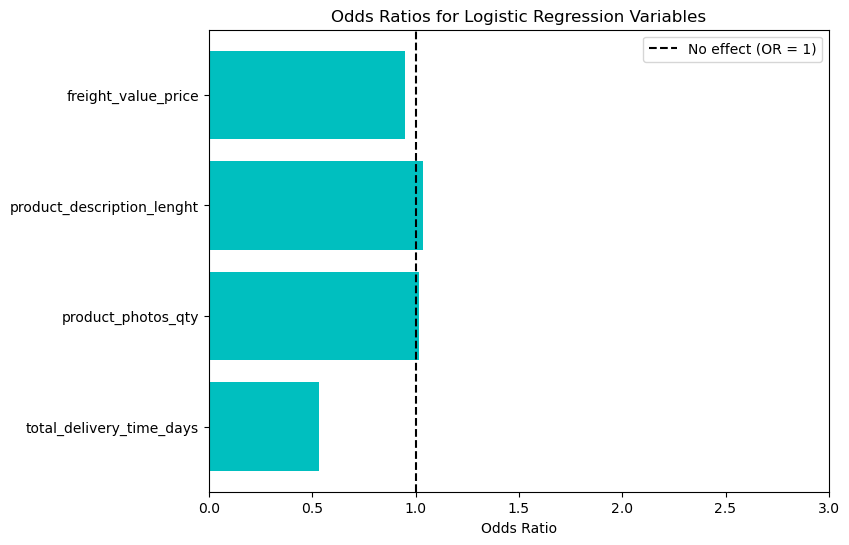

In [42]:
coef = np.array(coefficients)
features = ['total_delivery_time_days', 'product_photos_qty', 'product_description_lenght', 'freight_value_price']
odds_ratios = np.exp(coef)

plt.figure(figsize=(8, 6))
plt.barh(features, odds_ratios, color='c')
plt.axvline(x=1, color='black', linestyle='--', label='No effect (OR = 1)')
plt.xlabel('Odds Ratio')
plt.title('Odds Ratios for Logistic Regression Variables')
plt.xlim(0, 3)
plt.legend()
plt.show()

In [43]:
data['review_score'].value_counts()

review_score
5.000000    63152
4.000000    21198
1.000000    14617
3.000000     9437
2.000000     3895
4.500000       68
2.500000       46
3.500000       31
1.500000       18
3.333333        1
4.333333        1
Name: count, dtype: int64

In [44]:
data['review_score'].info

<bound method Series.info of 0         1.0
1         4.0
2         5.0
3         5.0
4         4.0
         ... 
113420    4.0
113421    5.0
113422    5.0
113423    5.0
113424    5.0
Name: review_score, Length: 113425, dtype: float64>

In [45]:
(1+18+31+46+3895+9437+14617)/113425*100

24.72558959664977

In [46]:
14617/113425*100

12.886929689221951

In [47]:
# 24.7 % of review scores are below 4 stars
# 12.9 % of review scores are even 1 star!!

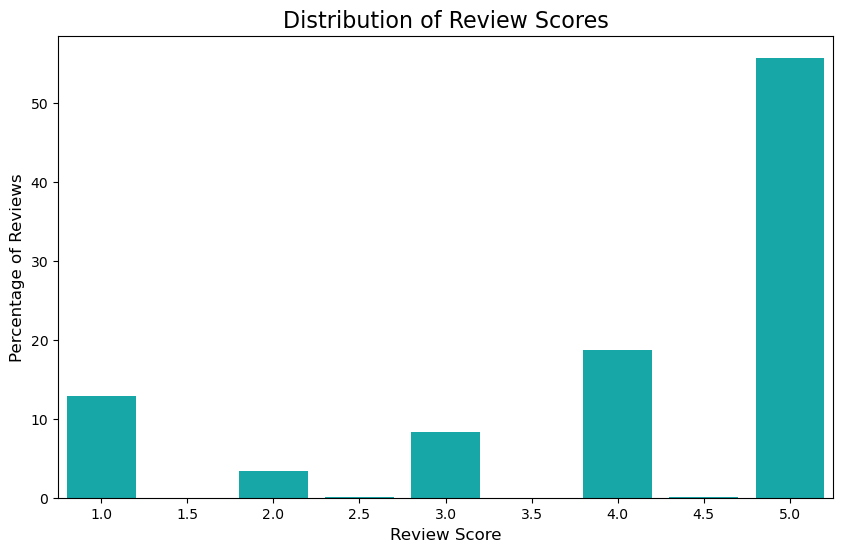

In [48]:
filtered_data = data[~data['review_score'].isin([3.333333333333333, 4.333333333333333])]
review_counts = filtered_data['review_score'].value_counts().sort_index()

plt.figure(figsize=(10, 6))
sns.barplot(x=review_counts.index, y=review_counts.values/113425*100, color='c')

plt.title('Distribution of Review Scores', fontsize=16)
plt.xlabel('Review Score', fontsize=12)
plt.ylabel('Percentage of Reviews', fontsize=12)
plt.show()